## Week Six - Assignment Data Sets

Brandon Chung 3/21/2026

## Instructions

Here is a dataset that shows a simple 2-node network:  the attendance of 18 Southern Women at 14 social events:

1. Brief Description. Small “musty” datasets like that from this 1941 study have proven very valuable in testing and comparing new network algorithms.
2. Dataset.
3. Python code to create dataset: https://networkx.github.io/documentation/stable/auto_examples/algorithms/plot_davis_club.html

What can you infer about the relationships between (1) the women, and (2) the social events?  

Please provide your code and analysis in an Jupyter notebook stored in your GitHub repository.

Biadjacency matrix
<Compressed Sparse Row sparse array of dtype 'int64'
	with 89 stored elements and shape (18, 14)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 7)	1
  (0, 8)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	1
  (1, 7)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	1
  (2, 4)	1
  (2, 5)	1
  (2, 6)	1
  (2, 7)	1
  (2, 8)	1
  (3, 0)	1
  (3, 2)	1
  :	:
  (12, 7)	1
  (12, 8)	1
  (12, 9)	1
  (12, 11)	1
  (12, 12)	1
  (12, 13)	1
  (13, 5)	1
  (13, 6)	1
  (13, 8)	1
  (13, 9)	1
  (13, 10)	1
  (13, 11)	1
  (13, 12)	1
  (13, 13)	1
  (14, 6)	1
  (14, 7)	1
  (14, 9)	1
  (14, 10)	1
  (14, 11)	1
  (15, 7)	1
  (15, 8)	1
  (16, 8)	1
  (16, 10)	1
  (17, 8)	1
  (17, 10)	1

#Friends, Member
17 Evelyn Jefferson
15 Laura Mandeville
17 Theresa Anderson
15 Brenda Rogers
11 Charlotte McDowd
15 Frances Anderson
15 Eleanor Nye
16 Pearl Oglethorpe
17 Ruth DeSand
17 Verne Sanderson
16 Myra Liddel
16 Katherina Rogers
17 Sylvia Avondale
17 Nora Fayette
1

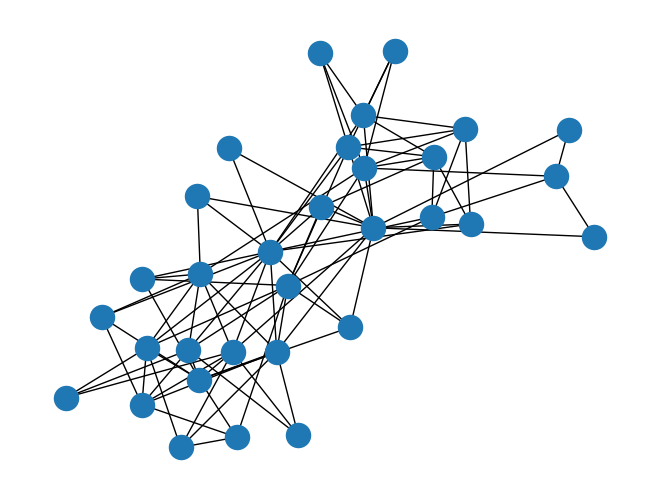

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite

# Loading bipartite graph and assigning women as primary or top network
G = nx.davis_southern_women_graph()
women = G.graph["top"]
clubs = G.graph["bottom"]

# Showing attendance data as biadjacency matrix: Value = 1 is attended 
print("Biadjacency matrix")
print(bipartite.biadjacency_matrix(G, women, clubs))

# project bipartite graph onto women nodes (unweighted) - two women are connected if they attended at least one event together (labeled as friends)
W = bipartite.projected_graph(G, women)
print()
print("#Friends, Member")
for w in women:
    print(f"{W.degree(w)} {w}")

# project bipartite graph onto women nodes keeping number of co-occurrence
# the degree computed is weighted and counts the total number of shared contacts
W = bipartite.weighted_projected_graph(G, women)
print()
print("#Friend meetings, Member")
for w in women:
    print(f"{W.degree(w, weight='weight')} {w}")

pos = nx.spring_layout(G, seed=648)  # Seed layout for reproducible node positions
nx.draw(G, pos)
plt.show()

In the provided code above we can see the biadjacency matrix, which is the attendance data for each women to specific events. We can also see the unweighted degree for each woman, which represents the number of women out of our 18 that have attended an event with. Lastly, we have the weighted projection where the printed degree represents the total number of shared event attendance. 

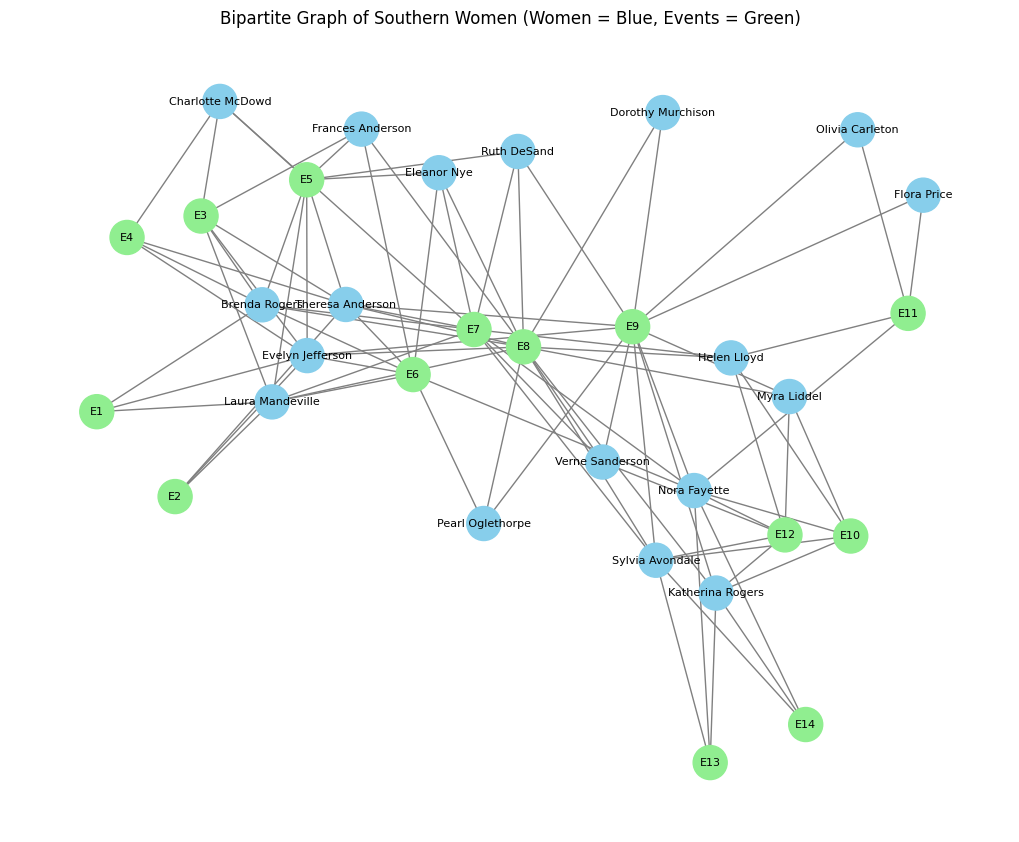

In [5]:
# Assign colors
color_map = []
for node in G.nodes():
    if node in women:
        color_map.append("skyblue")
    else:
        color_map.append("lightgreen") 

# Layout
pos = nx.spring_layout(G, seed=42)

# Draw graph
plt.figure(figsize=(10, 8))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,
    edge_color="gray",
    node_size=600,
    font_size=8
)

plt.title("Bipartite Graph of Southern Women (Women = Blue, Events = Green)")
plt.show()


Here I assigned colors to the bipartite network visualization for better interpretability. We can see that There seems to be two main groups of woman who typically attend events together, and for each of these two groups there are several (3 or 4) woman that are seen to attend events with their respective main groups depending on the event. 

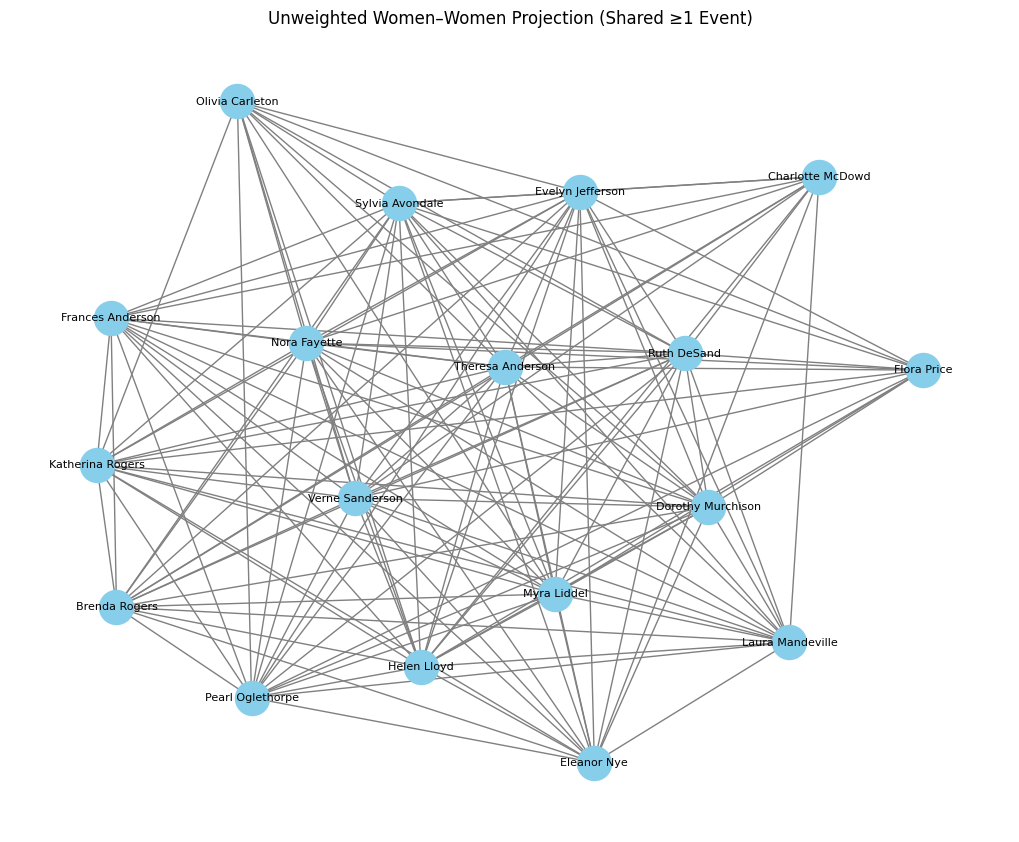

In [6]:
# Unweighted projection
W_unweighted = bipartite.projected_graph(G, women)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(W_unweighted, seed=42)

nx.draw(
    W_unweighted,
    pos,
    with_labels=True,
    node_color="skyblue",
    edge_color="gray",
    node_size=600,
    font_size=8
)

plt.title("Unweighted Women–Women Projection (Shared ≥1 Event)")
plt.show()


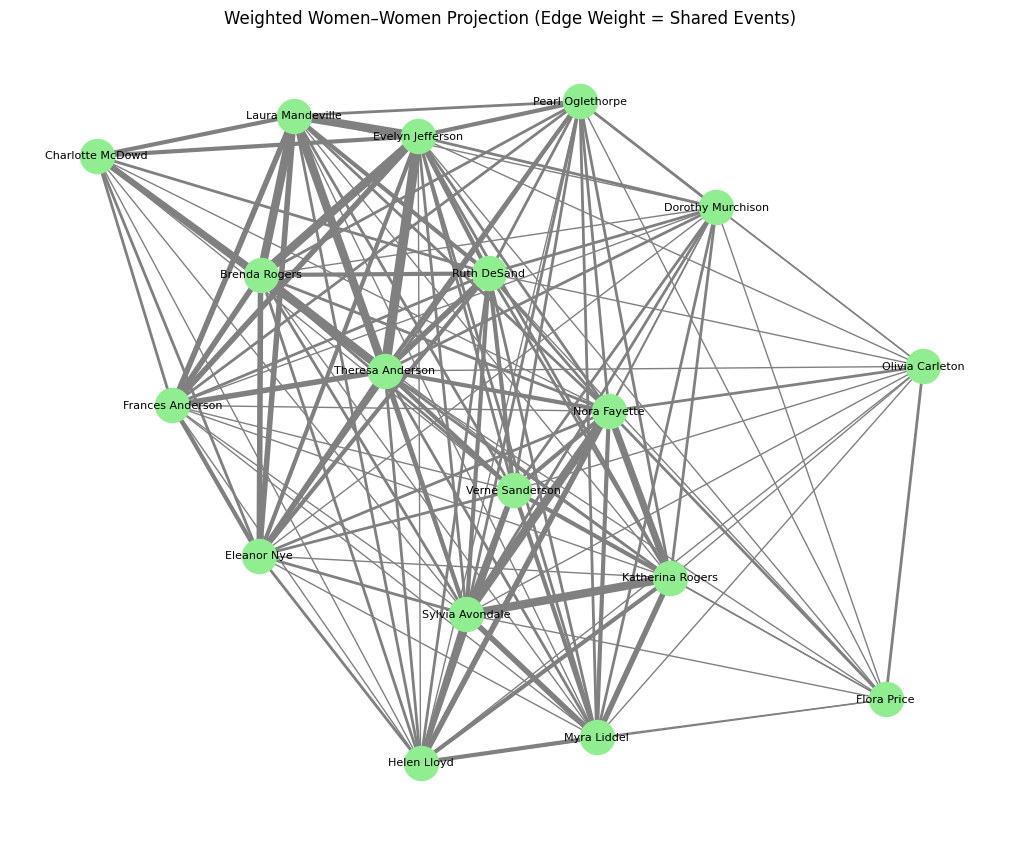

In [7]:
# Weighted projection
W_weighted = bipartite.weighted_projected_graph(G, women)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(W_weighted, seed=42)

# Extract weights for edge thickness
weights = [W_weighted[u][v]["weight"] for u, v in W_weighted.edges()]

nx.draw(
    W_weighted,
    pos,
    with_labels=True,
    node_color="lightgreen",
    edge_color="gray",
    width=weights,      # thicker edges = more shared events
    node_size=600,
    font_size=8
)

plt.title("Weighted Women–Women Projection (Edge Weight = Shared Events)")
plt.show()


## Inference of relationships

In [11]:
# Calculating centrality metrics on the weighted projection

W = bipartite.weighted_projected_graph(G, women)

# Centrality metrics
deg = nx.degree_centrality(W)
bet = nx.betweenness_centrality(W, weight='weight')
close = nx.closeness_centrality(W)
eig = nx.eigenvector_centrality(W, weight='weight')

print("Top women by degree:", sorted(deg.items(), key=lambda x: x[1], reverse=True)[:8])
print("Top women by betweenness:", sorted(bet.items(), key=lambda x: x[1], reverse=True)[:5])
print("Top women by eigenvector:", sorted(eig.items(), key=lambda x: x[1], reverse=True)[:5])


Top women by degree: [('Evelyn Jefferson', 1.0), ('Theresa Anderson', 1.0), ('Ruth DeSand', 1.0), ('Verne Sanderson', 1.0), ('Sylvia Avondale', 1.0), ('Nora Fayette', 1.0), ('Helen Lloyd', 1.0), ('Pearl Oglethorpe', 0.9411764705882353)]
Top women by betweenness: [('Olivia Carleton', 0.13628485485103134), ('Flora Price', 0.13628485485103134), ('Dorothy Murchison', 0.09577006939139289), ('Helen Lloyd', 0.06168870957473897), ('Frances Anderson', 0.057860644257703084)]
Top women by eigenvector: [('Theresa Anderson', 0.3535541948691951), ('Evelyn Jefferson', 0.31851926665283264), ('Brenda Rogers', 0.3042439827359832), ('Laura Mandeville', 0.3004069463983671), ('Sylvia Avondale', 0.2728783547604927)]


From the centrality metrics calculated on the weighted projection of events onto woman, we can see that there are 7 woman whom are connected to all the other woman in our data. Across the 14 social events recorded, these 7 woman are likely very socially active and attend events at higher frequency. In terms of betweeness Olivia and Flora are significantly higher than everyone else. They play important roles connecting the two social groups noted in the data. On our visualization we can see that although Olivia and Flora are peripheral nodes with smaller tie weights, they show connections across the two main groups. When comparing eigenvector centrality Theresa stands out with a score of 0.35 while most others plateau around 0.31. Theresa is likely the most popular woman in our data as she is most highly connected with other highly connected woman.

As for event relationships, events 6, 7, 8, and 9 are seen on our bipartite graph to be the events which connect the two main social groups the most. These events might represent outting at a more geographically favorable location, or larger / more important events. The other noted events are likely smaller or more intimate occasions where woman from each social group attend or even only subgroups from each main friend group. 

Video Presentation: https://youtu.be/gFS82m4W5L0